Note:
I measured the distance between each CTD sampling site and all eddy centers, then linked each site to its closest eddy center.
The classification is based entirely on geographic location (latitude and longitude), without considering time or date.
I didn’t use time-based classification because the time column contains unclear numeric values like 738281.5 instead of actual dates.
That’s why I used spatial distance — it’s a simpler and more reliable method in this situation.

The CTD distance from the nearest eddy center was classified following the method in Siegel et al. (2024) (see map below):
– "inside" for distances of 15 km or less
– "outside" for distances between 15 and 60 km
– "far" for distances greater than 60 km (added as an optional third category)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from itertools import combinations
from math import radians, cos, sin, asin, sqrt
from datetime import datetime

In [2]:
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2

# Load CTD sample metadata and eddy center coordinates
metadata_df = pd.read_excel("metadata.xlsx")
eddy_df = pd.read_excel("eddycenters_na.xlsx")

# Haversine formula to compute the distance between two geographic points (in km)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth’s radius in kilometers
    phi1, phi2 = radians(lat1), radians(lat2)
    delta_phi = radians(lat2 - lat1)
    delta_lambda = radians(lon2 - lon1)
    a = sin(delta_phi / 2)**2 + cos(phi1) * cos(phi2) * sin(delta_lambda / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

# Assign a spatial category based on distance (Siegel et al., 2024)
def classify_distance(distance_km):
    if distance_km <= 15:
        return "inside"
    elif distance_km <= 60:
        return "outside"
    else:
        return "far"

# For each CTD site, find the closest eddy center

results = []
for _, ctd_row in metadata_df.iterrows():
    ctd_lat = ctd_row['latitude']
    ctd_lon = ctd_row['longitude']
    profile_id = ctd_row['profileid']
    sample_date = ctd_row['sampledate'] if 'sampledate' in ctd_row else None

    # Calculate distances to all eddy centers
    distances = eddy_df.apply(
        lambda row: haversine(ctd_lat, ctd_lon, row['lat'], row['lon']), axis=1
    )
    min_idx = distances.idxmin()
    min_distance = distances[min_idx]
    nearest_eddy = eddy_df.loc[min_idx]
    eddy_time = nearest_eddy['time'] if 'time' in nearest_eddy else None

    # Save results for this CTD location
    results.append({
        "profileid": profile_id,
        "sampledate": sample_date,
        "ctd_lat": ctd_lat,
        "ctd_lon": ctd_lon,
        "nearest_eddy_lat": nearest_eddy['lat'],
        "nearest_eddy_lon": nearest_eddy['lon'],
        "eddy_time": eddy_time,
        "distance_km": min_distance,
        "location_category": classify_distance(min_distance)
    })

# Create a DataFrame with the results
classified_df = pd.DataFrame(results)

# Export to Excel
output_path = "eddy_centers_result.xlsx"
classified_df.to_excel(output_path, index=False)

# Print the results
pd.set_option('display.max_rows', None)
print(classified_df)
print(f"\nResults saved to {output_path}")


   profileid          sampledate   ctd_lat   ctd_lon  nearest_eddy_lat  \
0     ctd001 2021-05-04 17:50:48  48.78550 -14.88267         48.773252   
1     ctd002 2021-05-04 19:29:50  48.91333 -14.88000         48.942038   
2     ctd003 2021-05-04 21:20:42  49.04800 -14.87950         49.043811   
3     ctd004 2021-05-05 07:44:47  49.66667 -14.88000         49.086872   
4     ctd005 2021-05-05 14:37:00  49.03033 -14.85367         49.025121   
5     ctd006 2021-05-05 20:36:54  49.57817 -14.12367         49.083008   
6     ctd007 2021-05-05 23:07:11  49.57817 -14.12367         49.083008   
7     ctd008 2021-05-06 00:50:12  49.39317 -14.36533         49.083008   
8     ctd009 2021-05-06 02:30:00  49.28700 -14.50450         49.083008   
9     ctd010 2021-05-06 04:13:08  49.18117 -14.64333         49.083008   
10    ctd011 2021-05-06 05:57:56  49.08000 -14.77433         49.077472   
11    ctd012 2021-05-06 07:18:08  49.00983 -14.86450         49.017123   
12    ctd013 2021-05-06 09:58:18  49.0

In [5]:
# map: CTD and eddy locations

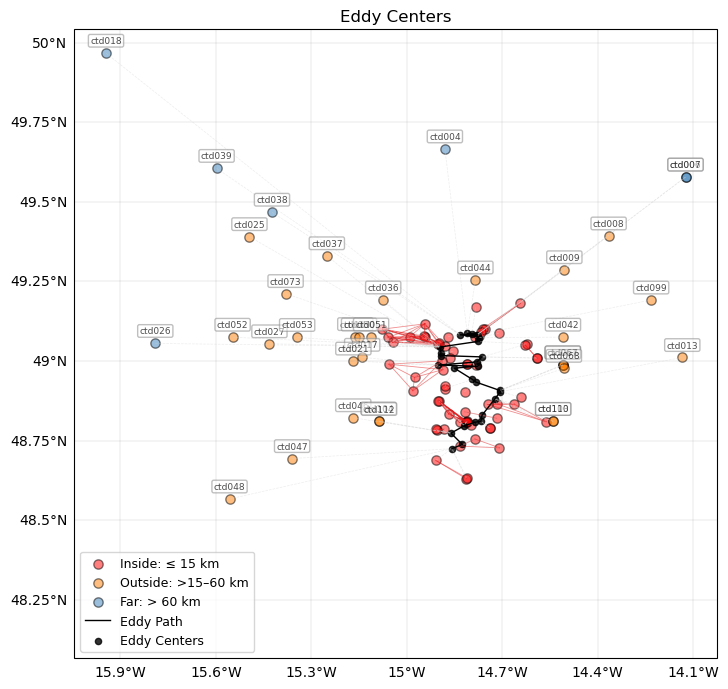

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from itertools import combinations

# Load the data
df = pd.read_excel("eddy_centers_result.xlsx")

# Rename the column for consistency
df = df.rename(columns={'location_category': 'eddy_classification'})

# Define colors and labels
color_map = {
    "inside": ("red", "Inside: ≤ 15 km"),
    "outside": ("#ff7f00", "Outside: >15–60 km"),
    "far": ("#377eb8", "Far: > 60 km")
}

# Create the map
plt.figure(figsize=(8, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor("white")

# Add geographic features
ax.coastlines(resolution='10m', linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='white')
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4)
gl.top_labels = gl.right_labels = False

# Draw lines between CTDs classified as "inside"
core_df = df[df["eddy_classification"] == "inside"]
for key, group in core_df.groupby(["nearest_eddy_lat", "nearest_eddy_lon"]):
    core_points = group[["ctd_lat", "ctd_lon"]].values
    for (lat1, lon1), (lat2, lon2) in combinations(core_points, 2):
        ax.plot([lon1, lon2], [lat1, lat2],
                color='#e41a1c', linewidth=0.6, alpha=0.5, linestyle='-')

# Draw dashed lines from CTD to eddy center
for _, row in df.iterrows():
    ax.plot([row["ctd_lon"], row["nearest_eddy_lon"]],
            [row["ctd_lat"], row["nearest_eddy_lat"]],
            color='lightgray', linewidth=0.5, alpha=0.4, linestyle='--')

# Scatter plot of CTDs by category
for key in ["inside", "outside", "far"]:
    group = df[df["eddy_classification"] == key]
    ax.scatter(group["ctd_lon"], group["ctd_lat"],
               color=color_map[key][0],
               label=color_map[key][1],
               s=45, edgecolor='black', alpha=0.5)

# Plot eddy centers and path
eddy_centers = df[["nearest_eddy_lat", "nearest_eddy_lon"]].drop_duplicates()
eddy_centers_sorted = eddy_centers.sort_values(by=["nearest_eddy_lat", "nearest_eddy_lon"])
ax.plot(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
        color='black', linewidth=1, linestyle='-', label="Eddy Path")
ax.scatter(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
           color='black', s=20, label="Eddy Centers", alpha=0.8)

# Map bounds
lon_min, lon_max = df["ctd_lon"].min() - 0.1, df["ctd_lon"].max() + 0.1
lat_min, lat_max = df["ctd_lat"].min() - 0.5, df["ctd_lat"].max() + 0.075
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# Label profile IDs for some categories
enable_labeling = True
if enable_labeling:
    for classification in ["outside", "far"]:
        group = df[df["eddy_classification"] == classification].copy()
        for i, (_, row) in enumerate(group.iterrows()):
            ax.text(row["ctd_lon"], row["ctd_lat"] + 0.025, str(row["profileid"]),
                    fontsize=6.5, ha='center', va='bottom',
                    color='black', alpha=0.7,
                    bbox=dict(facecolor='white', edgecolor='gray',
                              boxstyle='round,pad=0.2', alpha=0.5))

# Final touch
plt.title("Eddy Centers", fontsize=12)
plt.legend(title="", loc='lower left', fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.show()


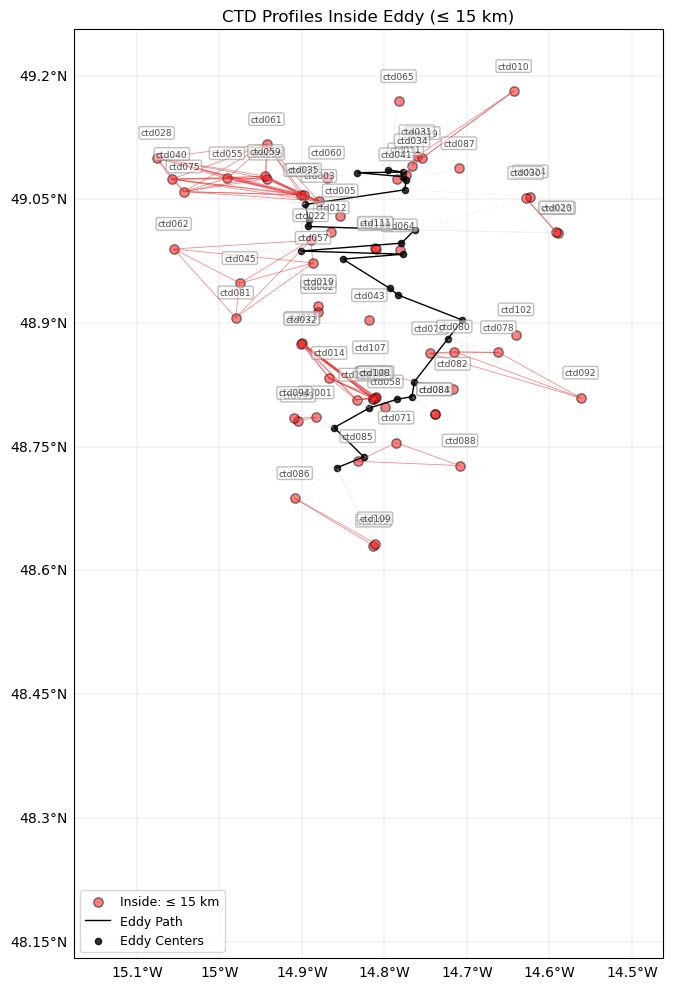

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from itertools import combinations

# === within (≤ 15 km) ===
df = pd.read_excel("eddy_centers_result.xlsx")
df = df.rename(columns={'location_category': 'eddy_classification'})
df = df[df["eddy_classification"] == "inside"]  # ✅ فقط داخل الدوامة

# === إعداد ألوان التصنيف الواحد (inside) ===
color_map = {
    "inside": ("red", "Inside: ≤ 15 km")
}

# === إنشاء الخريطة ===
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor("white")

# === خصائص الخريطة ===
ax.coastlines(resolution='10m', linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='white')
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4)
gl.top_labels = gl.right_labels = False

# === خطوط بين نقاط داخل الدوامة ===
for key, group in df.groupby(["nearest_eddy_lat", "nearest_eddy_lon"]):
    core_points = group[["ctd_lat", "ctd_lon"]].values
    for (lat1, lon1), (lat2, lon2) in combinations(core_points, 2):
        ax.plot([lon1, lon2], [lat1, lat2],
                color='#e41a1c', linewidth=0.6, alpha=0.5, linestyle='-')

# === خطوط من البروفايل إلى مركز الدوامة ===
for _, row in df.iterrows():
    ax.plot([row["ctd_lon"], row["nearest_eddy_lon"]],
            [row["ctd_lat"], row["nearest_eddy_lat"]],
            color='lightgray', linewidth=0.5, alpha=0.4, linestyle='--')

# === نقاط البروفايلات داخل الدوامة فقط ===
ax.scatter(df["ctd_lon"], df["ctd_lat"],
           color=color_map["inside"][0],
           label=color_map["inside"][1],
           s=45, edgecolor='black', alpha=0.5)

# === مراكز الدوامة ومسارها ===
eddy_centers = df[["nearest_eddy_lat", "nearest_eddy_lon"]].drop_duplicates()
eddy_centers_sorted = eddy_centers.sort_values(by=["nearest_eddy_lat", "nearest_eddy_lon"])
ax.plot(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
        color='black', linewidth=1, linestyle='-', label="Eddy Path")
ax.scatter(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
           color='black', s=20, label="Eddy Centers", alpha=0.8)

# === إعداد حدود الخريطة ===
lon_min, lon_max = df["ctd_lon"].min() - 0.1, df["ctd_lon"].max() + 0.1
lat_min, lat_max = df["ctd_lat"].min() - 0.5, df["ctd_lat"].max() + 0.075
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# === كتابة معرف البروفايل ===
for i, (_, row) in enumerate(df.iterrows()):
    ax.text(row["ctd_lon"], row["ctd_lat"] + 0.025, str(row["profileid"]),
            fontsize=6.5, ha='center', va='bottom',
            color='black', alpha=0.7,
            bbox=dict(facecolor='white', edgecolor='gray',
                      boxstyle='round,pad=0.2', alpha=0.5))

# === عنوان ونهائي ===
plt.title("CTD Profiles Inside Eddy (≤ 15 km)", fontsize=12)
plt.legend(title="", loc='lower left', fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.show()


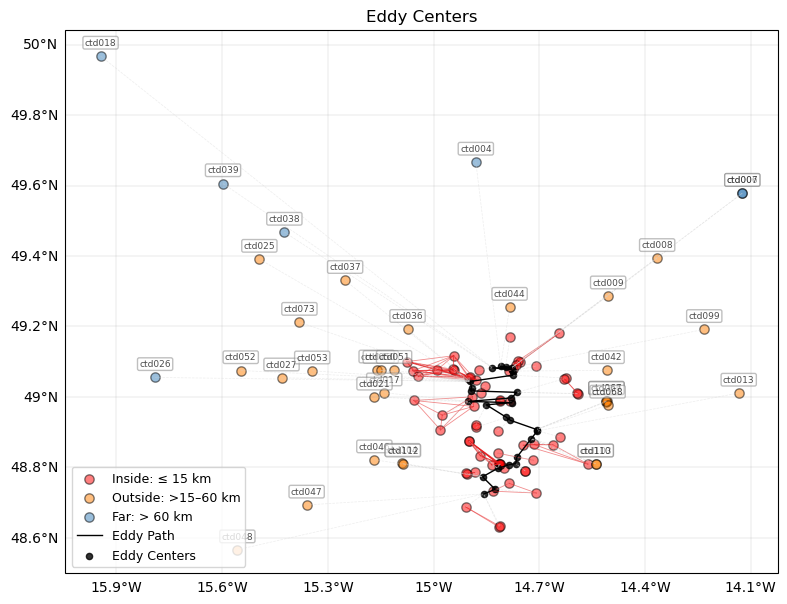

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from itertools import combinations

# Load the data
df = pd.read_excel("eddy_centers_result.xlsx")

# Rename the column for consistency
df = df.rename(columns={'location_category': 'eddy_classification'})

# Define colors and labels
color_map = {
    "inside": ("red", "Inside: ≤ 15 km"),
    "outside": ("#ff7f00", "Outside: >15–60 km"),
    "far": ("#377eb8", "Far: > 60 km")
}

# Create the map
plt.figure(figsize=(8, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor("white")

# Add geographic features
ax.coastlines(resolution='10m', linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='white')
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4)
gl.top_labels = gl.right_labels = False

# Draw lines between CTDs classified as "inside"
core_df = df[df["eddy_classification"] == "inside"]
for key, group in core_df.groupby(["nearest_eddy_lat", "nearest_eddy_lon"]):
    core_points = group[["ctd_lat", "ctd_lon"]].values
    for (lat1, lon1), (lat2, lon2) in combinations(core_points, 2):
        ax.plot([lon1, lon2], [lat1, lat2],
                color='#e41a1c', linewidth=0.6, alpha=0.5, linestyle='-')

# Draw dashed lines from CTD to eddy center
for _, row in df.iterrows():
    ax.plot([row["ctd_lon"], row["nearest_eddy_lon"]],
            [row["ctd_lat"], row["nearest_eddy_lat"]],
            color='lightgray', linewidth=0.5, alpha=0.4, linestyle='--')

# Scatter plot of CTDs by category
for key in ["inside", "outside", "far"]:
    group = df[df["eddy_classification"] == key]
    ax.scatter(group["ctd_lon"], group["ctd_lat"],
               color=color_map[key][0],
               label=color_map[key][1],
               s=45, edgecolor='black', alpha=0.5)

# Plot eddy centers and path
eddy_centers = df[["nearest_eddy_lat", "nearest_eddy_lon"]].drop_duplicates()
eddy_centers_sorted = eddy_centers.sort_values(by=["nearest_eddy_lat", "nearest_eddy_lon"])
ax.plot(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
        color='black', linewidth=1, linestyle='-', label="Eddy Path")
ax.scatter(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
           color='black', s=20, label="Eddy Centers", alpha=0.8)

# === Map bounds with fixed lat_min = 48.5 ===
lon_min, lon_max = df["ctd_lon"].min() - 0.1, df["ctd_lon"].max() + 0.1
lat_min = 48.5
lat_max = df["ctd_lat"].max() + 0.075
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# Label profile IDs for some categories
enable_labeling = True
if enable_labeling:
    for classification in ["outside", "far"]:
        group = df[df["eddy_classification"] == classification].copy()
        for i, (_, row) in enumerate(group.iterrows()):
            ax.text(row["ctd_lon"], row["ctd_lat"] + 0.025, str(row["profileid"]),
                    fontsize=6.5, ha='center', va='bottom',
                    color='black', alpha=0.7,
                    bbox=dict(facecolor='white', edgecolor='gray',
                              boxstyle='round,pad=0.2', alpha=0.5))

# Final touch
plt.title("Eddy Centers", fontsize=12)
plt.legend(title="", loc='lower left', fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.show()


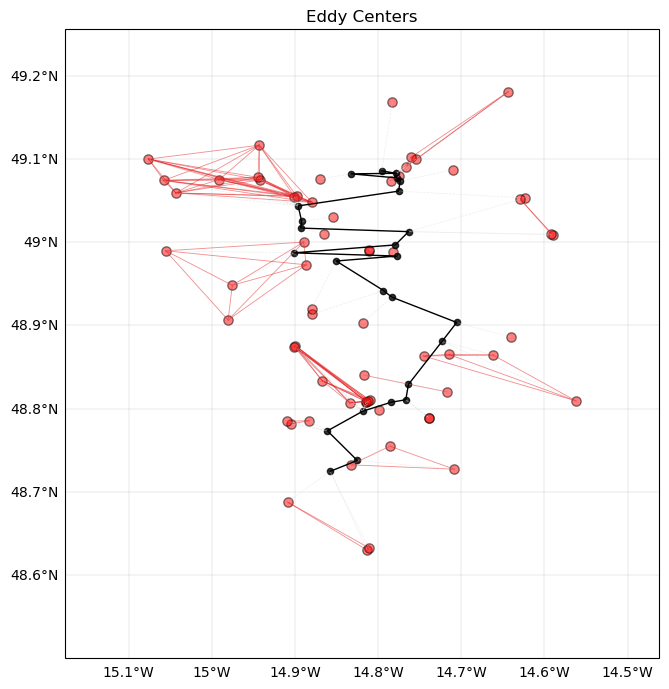

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from itertools import combinations

# Load the data
df = pd.read_excel("eddy_centers_result.xlsx")

# ✅ Filter only 'inside' profiles (≤ 15 km)
df = df[df["location_category"] == "inside"]

# Rename the column for consistency
df = df.rename(columns={'location_category': 'eddy_classification'})

# Define colors and labels
color_map = {
    "inside": ("red", "Inside: ≤ 15 km"),
    "outside": ("#ff7f00", "Outside: >15–60 km"),
    "far": ("#377eb8", "Far: > 60 km")
}

# Create the map
plt.figure(figsize=(8, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor("white")

# Add geographic features
ax.coastlines(resolution='10m', linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='white')
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4)
gl.top_labels = gl.right_labels = False

# Draw lines between CTDs classified as "inside"
core_df = df[df["eddy_classification"] == "inside"]
for key, group in core_df.groupby(["nearest_eddy_lat", "nearest_eddy_lon"]):
    core_points = group[["ctd_lat", "ctd_lon"]].values
    for (lat1, lon1), (lat2, lon2) in combinations(core_points, 2):
        ax.plot([lon1, lon2], [lat1, lat2],
                color='#e41a1c', linewidth=0.6, alpha=0.5, linestyle='-')

# Draw dashed lines from CTD to eddy center
for _, row in df.iterrows():
    ax.plot([row["ctd_lon"], row["nearest_eddy_lon"]],
            [row["ctd_lat"], row["nearest_eddy_lat"]],
            color='lightgray', linewidth=0.5, alpha=0.4, linestyle='--')

# Scatter plot of CTDs by category
for key in ["inside", "outside", "far"]:
    group = df[df["eddy_classification"] == key]
    ax.scatter(group["ctd_lon"], group["ctd_lat"],
               color=color_map[key][0],
               label=color_map[key][1],
               s=45, edgecolor='black', alpha=0.5)

# Plot eddy centers and path
eddy_centers = df[["nearest_eddy_lat", "nearest_eddy_lon"]].drop_duplicates()
eddy_centers_sorted = eddy_centers.sort_values(by=["nearest_eddy_lat", "nearest_eddy_lon"])
ax.plot(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
        color='black', linewidth=1, linestyle='-', label="Eddy Path")
ax.scatter(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
           color='black', s=20, label="Eddy Centers", alpha=0.8)

# === Map bounds with fixed lat_min = 48.5 ===
lon_min, lon_max = df["ctd_lon"].min() - 0.1, df["ctd_lon"].max() + 0.1
lat_min = 48.5
lat_max = df["ctd_lat"].max() + 0.075
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# Label profile IDs for some categories
enable_labeling = True
if enable_labeling:
    for classification in ["outside", "far"]:
        group = df[df["eddy_classification"] == classification].copy()
        for i, (_, row) in enumerate(group.iterrows()):
            ax.text(row["ctd_lon"], row["ctd_lat"] + 0.025, str(row["profileid"]),
                    fontsize=6.5, ha='center', va='bottom',
                    color='black', alpha=0.7,
                    bbox=dict(facecolor='white', edgecolor='gray',
                              boxstyle='round,pad=0.2', alpha=0.5))

# Final touch
plt.title("Eddy Centers", fontsize=12)
#plt.legend(title="", loc='lower left', fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.show()


   profileid          sampledate  distance_km   ctd_lat   ctd_lon  \
0     ctd001 2021-05-04 17:50:48     2.095781  48.78550 -14.88267   
1     ctd002 2021-05-04 19:29:50     7.080340  48.91333 -14.88000   
2     ctd003 2021-05-04 21:20:42     1.297195  49.04800 -14.87950   
4     ctd005 2021-05-05 14:37:00     2.847419  49.03033 -14.85367   
9     ctd010 2021-05-06 04:13:08    14.660926  49.18117 -14.64333   
10    ctd011 2021-05-06 05:57:56     0.346551  49.08000 -14.77433   
11    ctd012 2021-05-06 07:18:08     2.235757  49.00983 -14.86450   
13    ctd014 2021-05-06 15:09:53     5.390770  48.83333 -14.86700   
14    ctd015 2021-05-07 01:54:02    12.659492  49.00900 -14.58983   
17    ctd019 2021-05-07 14:28:03     6.732368  48.92020 -14.88000   
18    ctd020 2021-05-07 18:07:41    12.529029  49.00982 -14.59158   
20    ctd022 2021-05-11 17:18:49     1.678486  49.00026 -14.88950   
21    ctd023 2021-05-12 04:13:39    10.605447  48.87582 -14.89980   
22    ctd024 2021-05-12 07:11:56  

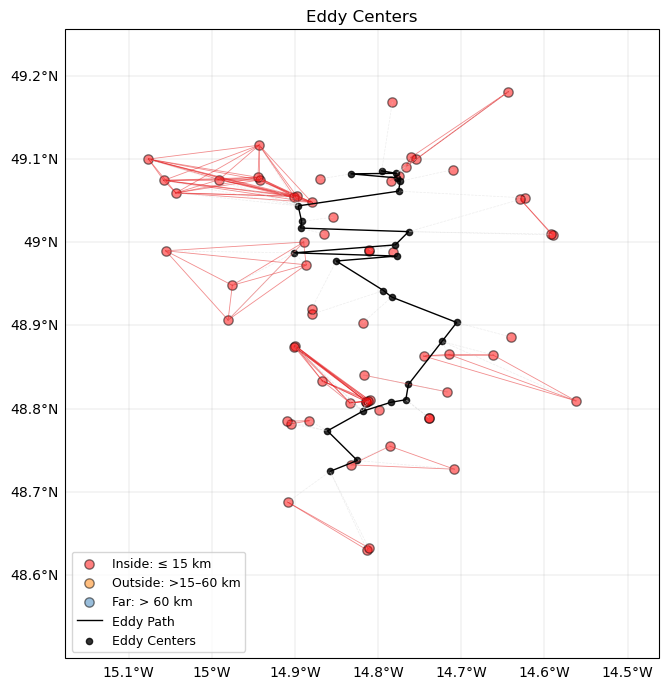

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from itertools import combinations

# Load the data
df = pd.read_excel("eddy_centers_result.xlsx")

# ✅ Filter only 'inside' profiles (≤ 15 km)
df = df[df["location_category"] == "inside"]

# ✅ Print profileid, sampledate, distance, lat/lon for profiles at lat ≥ 48.6
print(df[df["ctd_lat"] >= 48.6][["profileid", "sampledate", "distance_km", "ctd_lat", "ctd_lon", "nearest_eddy_lat"]])

# Rename the column for consistency
df = df.rename(columns={'location_category': 'eddy_classification'})

# Define colors and labels
color_map = {
    "inside": ("red", "Inside: ≤ 15 km"),
    "outside": ("#ff7f00", "Outside: >15–60 km"),
    "far": ("#377eb8", "Far: > 60 km")
}

# Create the map
plt.figure(figsize=(8, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor("white")

# Add geographic features
ax.coastlines(resolution='10m', linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='white')
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4)
gl.top_labels = gl.right_labels = False

# Draw lines between CTDs classified as "inside"
core_df = df[df["eddy_classification"] == "inside"]
for key, group in core_df.groupby(["nearest_eddy_lat", "nearest_eddy_lon"]):
    core_points = group[["ctd_lat", "ctd_lon"]].values
    for (lat1, lon1), (lat2, lon2) in combinations(core_points, 2):
        ax.plot([lon1, lon2], [lat1, lat2],
                color='#e41a1c', linewidth=0.6, alpha=0.5, linestyle='-')

# Draw dashed lines from CTD to eddy center
for _, row in df.iterrows():
    ax.plot([row["ctd_lon"], row["nearest_eddy_lon"]],
            [row["ctd_lat"], row["nearest_eddy_lat"]],
            color='lightgray', linewidth=0.5, alpha=0.4, linestyle='--')

# Scatter plot of CTDs by category
for key in ["inside", "outside", "far"]:
    group = df[df["eddy_classification"] == key]
    ax.scatter(group["ctd_lon"], group["ctd_lat"],
               color=color_map[key][0],
               label=color_map[key][1],
               s=45, edgecolor='black', alpha=0.5)

# Plot eddy centers and path
eddy_centers = df[["nearest_eddy_lat", "nearest_eddy_lon"]].drop_duplicates()
eddy_centers_sorted = eddy_centers.sort_values(by=["nearest_eddy_lat", "nearest_eddy_lon"])
ax.plot(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
        color='black', linewidth=1, linestyle='-', label="Eddy Path")
ax.scatter(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
           color='black', s=20, label="Eddy Centers", alpha=0.8)

# === Map bounds with fixed lat_min = 48.5 ===
lon_min, lon_max = df["ctd_lon"].min() - 0.1, df["ctd_lon"].max() + 0.1
lat_min = 48.5
lat_max = df["ctd_lat"].max() + 0.075
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# Label profile IDs for some categories
enable_labeling = True
if enable_labeling:
    for classification in ["outside", "far"]:
        group = df[df["eddy_classification"] == classification].copy()
        for i, (_, row) in enumerate(group.iterrows()):
            ax.text(row["ctd_lon"], row["ctd_lat"] + 0.025, str(row["profileid"]),
                    fontsize=6.5, ha='center', va='bottom',
                    color='black', alpha=0.7,
                    bbox=dict(facecolor='white', edgecolor='gray',
                              boxstyle='round,pad=0.2', alpha=0.5))

# Final touch
plt.title("Eddy Centers", fontsize=12)
plt.legend(title="", loc='lower left', fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.show()


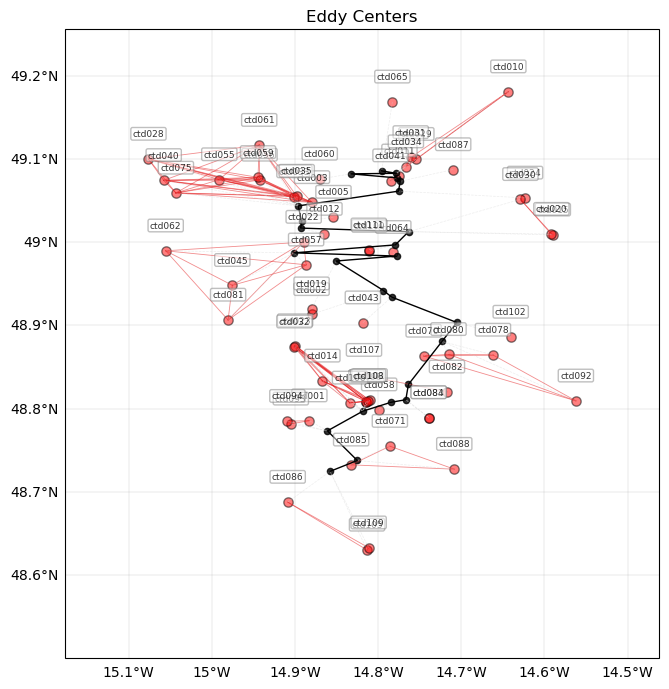

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from itertools import combinations

# ✅ Label 'inside' profileid on map if lat ≥ 48.6
def label_inside_profiles(df, ax):
    subset = df[(df["eddy_classification"] == "inside") & (df["ctd_lat"] >= 48.6)]
    for _, row in subset.iterrows():
        ax.text(row["ctd_lon"], row["ctd_lat"] + 0.025, str(row["profileid"]),
                fontsize=6.5, ha='center', va='bottom',
                color='black', alpha=0.8,
                bbox=dict(facecolor='white', edgecolor='gray',
                          boxstyle='round,pad=0.2', alpha=0.5))

# Load the data
df = pd.read_excel("eddy_centers_result.xlsx")

# ✅ Filter only 'inside' profiles (≤ 15 km)
df = df[df["location_category"] == "inside"]

# Rename the column for consistency
df = df.rename(columns={'location_category': 'eddy_classification'})

# Define colors and labels
color_map = {
    "inside": ("red", "Inside: ≤ 15 km"),
    "outside": ("#ff7f00", "Outside: >15–60 km"),
    "far": ("#377eb8", "Far: > 60 km")
}

# Create the map
plt.figure(figsize=(8, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor("white")

# Add geographic features
ax.coastlines(resolution='10m', linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='white')
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4)
gl.top_labels = gl.right_labels = False

# Draw lines between CTDs classified as "inside"
core_df = df[df["eddy_classification"] == "inside"]
for key, group in core_df.groupby(["nearest_eddy_lat", "nearest_eddy_lon"]):
    core_points = group[["ctd_lat", "ctd_lon"]].values
    for (lat1, lon1), (lat2, lon2) in combinations(core_points, 2):
        ax.plot([lon1, lon2], [lat1, lat2],
                color='#e41a1c', linewidth=0.6, alpha=0.5, linestyle='-')

# Draw dashed lines from CTD to eddy center
for _, row in df.iterrows():
    ax.plot([row["ctd_lon"], row["nearest_eddy_lon"]],
            [row["ctd_lat"], row["nearest_eddy_lat"]],
            color='lightgray', linewidth=0.5, alpha=0.4, linestyle='--')

# Scatter plot of CTDs by category
for key in ["inside", "outside", "far"]:
    group = df[df["eddy_classification"] == key]
    ax.scatter(group["ctd_lon"], group["ctd_lat"],
               color=color_map[key][0],
               label=color_map[key][1],
               s=45, edgecolor='black', alpha=0.5)

# Plot eddy centers and path
eddy_centers = df[["nearest_eddy_lat", "nearest_eddy_lon"]].drop_duplicates()
eddy_centers_sorted = eddy_centers.sort_values(by=["nearest_eddy_lat", "nearest_eddy_lon"])
ax.plot(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
        color='black', linewidth=1, linestyle='-', label="Eddy Path")
ax.scatter(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
           color='black', s=20, label="Eddy Centers", alpha=0.8)

# === Map bounds with fixed lat_min = 48.5 ===
lon_min, lon_max = df["ctd_lon"].min() - 0.1, df["ctd_lon"].max() + 0.1
lat_min = 48.5
lat_max = df["ctd_lat"].max() + 0.075
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# Label profile IDs for "outside" and "far"
enable_labeling = True
if enable_labeling:
    for classification in ["outside", "far"]:
        group = df[df["eddy_classification"] == classification].copy()
        for i, (_, row) in enumerate(group.iterrows()):
            ax.text(row["ctd_lon"], row["ctd_lat"] + 0.025, str(row["profileid"]),
                    fontsize=6.5, ha='center', va='bottom',
                    color='black', alpha=0.7,
                    bbox=dict(facecolor='white', edgecolor='gray',
                              boxstyle='round,pad=0.2', alpha=0.5))

# ✅ Label 'inside' profileid where ctd_lat ≥ 48.6
label_inside_profiles(df, ax)

# Final touch
plt.title("Eddy Centers", fontsize=12)
#plt.legend(title="", loc='lower left', fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.show()


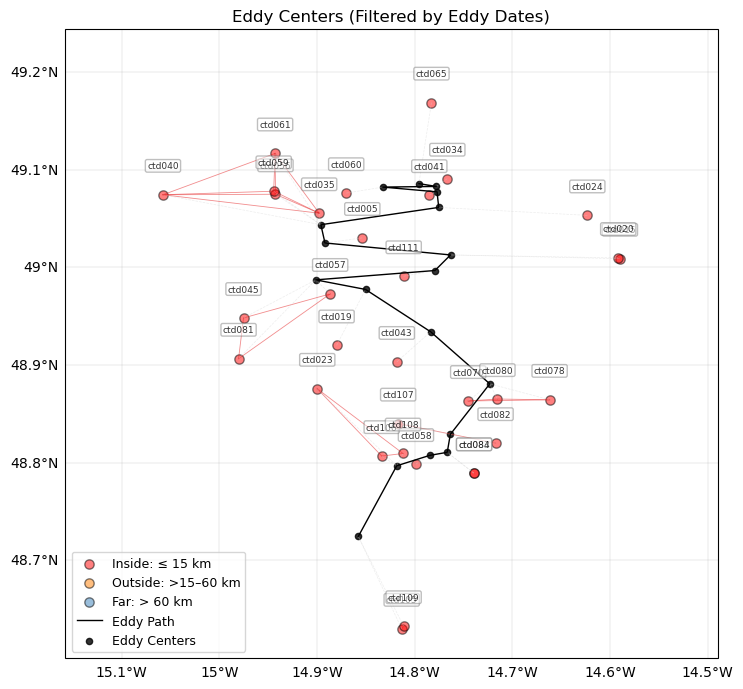

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from itertools import combinations

# ✅ Label 'inside' profileid on map if lat ≥ 48.6
def label_inside_profiles(df, ax):
    subset = df[(df["eddy_classification"] == "inside") & (df["ctd_lat"] >= 48.6)]
    for _, row in subset.iterrows():
        ax.text(row["ctd_lon"], row["ctd_lat"] + 0.025, str(row["profileid"]),
                fontsize=6.5, ha='center', va='bottom',
                color='black', alpha=0.8,
                bbox=dict(facecolor='white', edgecolor='gray',
                          boxstyle='round,pad=0.2', alpha=0.5))

# Load the data
df = pd.read_excel("eddy_centers_result.xlsx")

# ✅ Keep only profiles from eddy_dates
eddy_dates = [
    "2021-05-05", "2021-05-07", "2021-05-12", "2021-05-14",
    "2021-05-16", "2021-05-19", "2021-05-22", "2021-05-25", "2021-05-29"
]
df["sampledate"] = pd.to_datetime(df["sampledate"], errors="coerce")
df = df[df["sampledate"].dt.date.isin(pd.to_datetime(eddy_dates).date)]

# ✅ Filter only 'inside' profiles (≤ 15 km)
df = df[df["location_category"] == "inside"]

# Rename the column for consistency
df = df.rename(columns={'location_category': 'eddy_classification'})

# Define colors and labels
color_map = {
    "inside": ("red", "Inside: ≤ 15 km"),
    "outside": ("#ff7f00", "Outside: >15–60 km"),
    "far": ("#377eb8", "Far: > 60 km")
}

# Create the map
plt.figure(figsize=(8, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor("white")

# Add geographic features
ax.coastlines(resolution='10m', linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='white')
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4)
gl.top_labels = gl.right_labels = False

# Draw lines between CTDs classified as "inside"
core_df = df[df["eddy_classification"] == "inside"]
for key, group in core_df.groupby(["nearest_eddy_lat", "nearest_eddy_lon"]):
    core_points = group[["ctd_lat", "ctd_lon"]].values
    for (lat1, lon1), (lat2, lon2) in combinations(core_points, 2):
        ax.plot([lon1, lon2], [lat1, lat2],
                color='#e41a1c', linewidth=0.6, alpha=0.5, linestyle='-')

# Draw dashed lines from CTD to eddy center
for _, row in df.iterrows():
    ax.plot([row["ctd_lon"], row["nearest_eddy_lon"]],
            [row["ctd_lat"], row["nearest_eddy_lat"]],
            color='lightgray', linewidth=0.5, alpha=0.4, linestyle='--')

# Scatter plot of CTDs by category
for key in ["inside", "outside", "far"]:
    group = df[df["eddy_classification"] == key]
    ax.scatter(group["ctd_lon"], group["ctd_lat"],
               color=color_map[key][0],
               label=color_map[key][1],
               s=45, edgecolor='black', alpha=0.5)

# Plot eddy centers and path
eddy_centers = df[["nearest_eddy_lat", "nearest_eddy_lon"]].drop_duplicates()
eddy_centers_sorted = eddy_centers.sort_values(by=["nearest_eddy_lat", "nearest_eddy_lon"])
ax.plot(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
        color='black', linewidth=1, linestyle='-', label="Eddy Path")
ax.scatter(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
           color='black', s=20, label="Eddy Centers", alpha=0.8)

# === Map bounds with fixed lat_min = 48.5 ===
lon_min, lon_max = df["ctd_lon"].min() - 0.1, df["ctd_lon"].max() + 0.1
lat_min = 48.6
lat_max = df["ctd_lat"].max() + 0.075
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# Label profile IDs for "outside" and "far"
enable_labeling = True
if enable_labeling:
    for classification in ["outside", "far"]:
        group = df[df["eddy_classification"] == classification].copy()
        for i, (_, row) in enumerate(group.iterrows()):
            ax.text(row["ctd_lon"], row["ctd_lat"] + 0.025, str(row["profileid"]),
                    fontsize=6.5, ha='center', va='bottom',
                    color='black', alpha=0.7,
                    bbox=dict(facecolor='white', edgecolor='gray',
                              boxstyle='round,pad=0.2', alpha=0.5))

# ✅ Label 'inside' profileid where ctd_lat ≥ 48.6
label_inside_profiles(df, ax)

# Final touch
plt.title("Eddy Centers (Filtered by Eddy Dates)", fontsize=12)
plt.legend(title="", loc='lower left', fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.show()


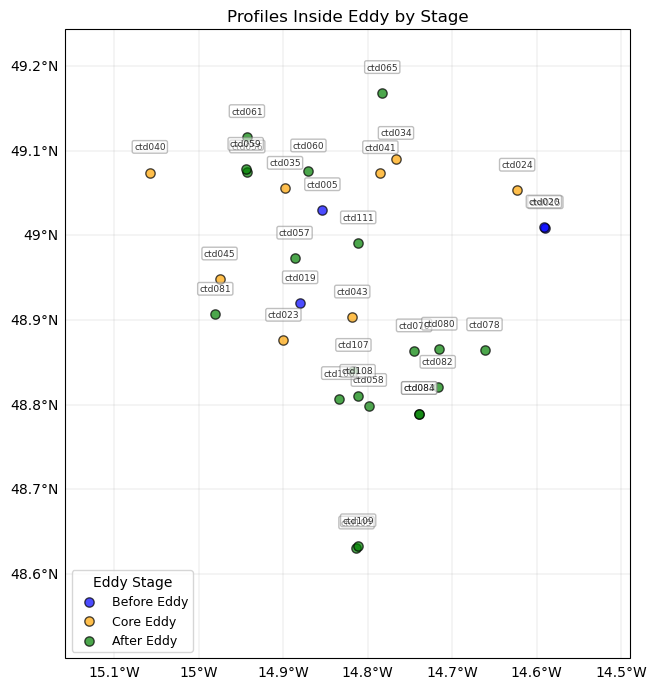

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# === 1. تحميل البيانات ===
df = pd.read_excel("eddy_centers_result.xlsx")

# === 2. تنسيق التواريخ وتصفية فقط داخل الدوامة ===
eddy_dates = [
    "2021-05-05", "2021-05-07", "2021-05-12", "2021-05-14",
    "2021-05-16", "2021-05-19", "2021-05-22", "2021-05-25", "2021-05-29"
]
df["sampledate"] = pd.to_datetime(df["sampledate"], errors="coerce")
df = df[df["sampledate"].dt.date.isin(pd.to_datetime(eddy_dates).date)]

df = df[df["location_category"] == "inside"]
df = df.rename(columns={"location_category": "eddy_classification"})

# === 3. تصنيف المرحلة: قبل - أثناء - بعد الدوامة ===
before_dates = pd.to_datetime(["2021-05-05", "2021-05-07"]).date
core_dates = pd.to_datetime(["2021-05-12", "2021-05-14", "2021-05-16"]).date
after_dates = pd.to_datetime(["2021-05-19", "2021-05-22", "2021-05-25", "2021-05-29"]).date

df["date_only"] = df["sampledate"].dt.date

def classify_stage(date):
    if date in before_dates:
        return "before"
    elif date in core_dates:
        return "core"
    elif date in after_dates:
        return "after"
    else:
        return "unknown"

df["stage"] = df["date_only"].apply(classify_stage)

# === 4. إعداد ألوان كل مرحلة ===
stage_colors = {
    "before": "blue",
    "core": "orange",
    "after": "green"
}

# === 5. رسم الخريطة ===
plt.figure(figsize=(9, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor("white")

# معالم الخريطة
ax.coastlines(resolution='10m', linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='white')
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4)
gl.top_labels = gl.right_labels = False

# رسم النقاط حسب المرحلة
for stage, color in stage_colors.items():
    group = df[df["stage"] == stage]
    ax.scatter(group["ctd_lon"], group["ctd_lat"],
               color=color, s=45, edgecolor='black', alpha=0.7,
               label=f"{stage.capitalize()} Eddy")

    # عرض معرف البروفايل
    for _, row in group.iterrows():
        ax.text(row["ctd_lon"], row["ctd_lat"] + 0.025, str(row["profileid"]),
                fontsize=6.5, ha='center', va='bottom',
                color='black', alpha=0.8,
                bbox=dict(facecolor='white', edgecolor='gray',
                          boxstyle='round,pad=0.2', alpha=0.5))

# حدود الخريطة
lon_min, lon_max = df["ctd_lon"].min() - 0.1, df["ctd_lon"].max() + 0.1
lat_min = 48.5
lat_max = df["ctd_lat"].max() + 0.075
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# عنوان وخاتمة
plt.title("Profiles Inside Eddy by Stage", fontsize=12)
plt.legend(title="Eddy Stage", loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()


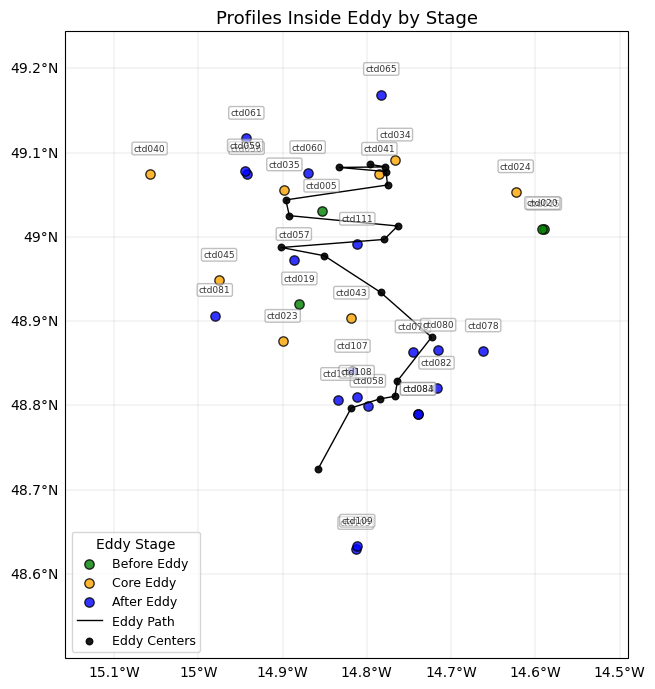

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# === 1. تحميل البيانات ===
df = pd.read_excel("eddy_centers_result.xlsx")

# === 2. فلترة فقط داخل الدوامة وتواريخ محددة ===
eddy_dates = [
    "2021-05-05", "2021-05-07", "2021-05-12", "2021-05-14",
    "2021-05-16", "2021-05-19", "2021-05-22", "2021-05-25", "2021-05-29"
]
df["sampledate"] = pd.to_datetime(df["sampledate"], errors="coerce")
df = df[df["sampledate"].dt.date.isin(pd.to_datetime(eddy_dates).date)]
df = df[df["location_category"] == "inside"]
df = df.rename(columns={"location_category": "eddy_classification"})

# === 3. تصنيف المراحل ===
before_dates = pd.to_datetime(["2021-05-05", "2021-05-07"]).date
core_dates = pd.to_datetime(["2021-05-12", "2021-05-14", "2021-05-16"]).date
after_dates = pd.to_datetime(["2021-05-19", "2021-05-22", "2021-05-25", "2021-05-29"]).date

df["date_only"] = df["sampledate"].dt.date

def classify_stage(date):
    if date in before_dates:
        return "before"
    elif date in core_dates:
        return "core"
    elif date in after_dates:
        return "after"
    else:
        return "unknown"

df["stage"] = df["date_only"].apply(classify_stage)

# === 4. إعداد الألوان حسب المرحلة ===
stage_colors = {
    "before": "green",
    "core": "orange",
    "after": "blue"
}

# === 5. رسم الخريطة ===
plt.figure(figsize=(9, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor("white")

# معالم الخريطة
ax.coastlines(resolution='10m', linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='white')
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4)
gl.top_labels = gl.right_labels = False

# رسم النقاط حسب المرحلة
for stage, color in stage_colors.items():
    group = df[df["stage"] == stage]
    ax.scatter(group["ctd_lon"], group["ctd_lat"],
               color=color, s=45, edgecolor='black', alpha=0.8,
               label=f"{stage.capitalize()} Eddy")

    # عرض معرف البروفايل
    for _, row in group.iterrows():
        ax.text(row["ctd_lon"], row["ctd_lat"] + 0.025, str(row["profileid"]),
                fontsize=6.5, ha='center', va='bottom',
                color='black', alpha=0.8,
                bbox=dict(facecolor='white', edgecolor='gray',
                          boxstyle='round,pad=0.2', alpha=0.5))

# === 6. رسم مراكز الدوامة والمسار ===
eddy_centers = df[["nearest_eddy_lat", "nearest_eddy_lon"]].drop_duplicates()
eddy_centers_sorted = eddy_centers.sort_values(by=["nearest_eddy_lat", "nearest_eddy_lon"])

# رسم المسار
ax.plot(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
        color='black', linewidth=1, linestyle='-', label="Eddy Path")

# رسم النقاط السوداء لمراكز الدوامة
ax.scatter(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
           color='black', s=22, label="Eddy Centers", alpha=0.9)

# حدود الخريطة
lon_min, lon_max = df["ctd_lon"].min() - 0.1, df["ctd_lon"].max() + 0.1
lat_min = 48.5
lat_max = df["ctd_lat"].max() + 0.075
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# عنوان وخاتمة
plt.title("Profiles Inside Eddy by Stage", fontsize=13)
plt.legend(title="Eddy Stage", loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()


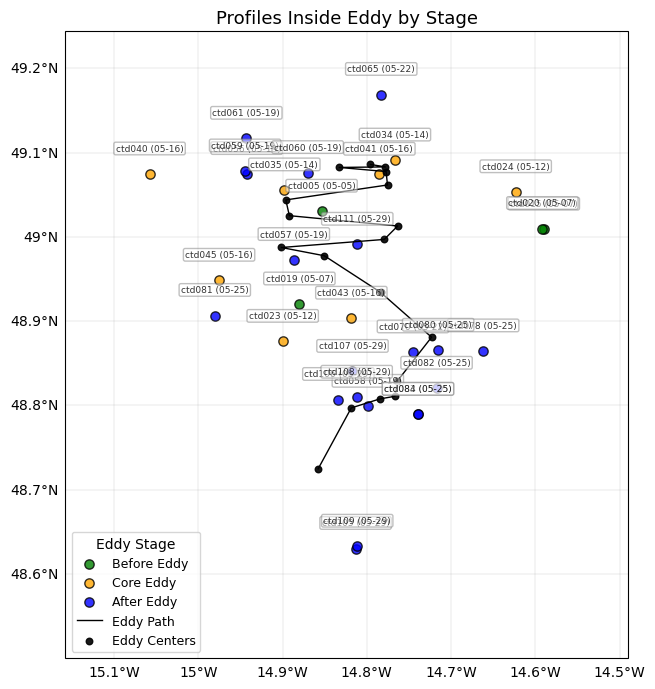

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# === 1. تحميل البيانات ===
df = pd.read_excel("eddy_centers_result.xlsx")

# === 2. فلترة فقط داخل الدوامة وتواريخ محددة ===
eddy_dates = [
    "2021-05-05", "2021-05-07", "2021-05-12", "2021-05-14",
    "2021-05-16", "2021-05-19", "2021-05-22", "2021-05-25", "2021-05-29"
]
df["sampledate"] = pd.to_datetime(df["sampledate"], errors="coerce")
df = df[df["sampledate"].dt.date.isin(pd.to_datetime(eddy_dates).date)]
df = df[df["location_category"] == "inside"]
df = df.rename(columns={"location_category": "eddy_classification"})

# === 3. تصنيف المراحل ===
before_dates = pd.to_datetime(["2021-05-05", "2021-05-07"]).date
core_dates = pd.to_datetime(["2021-05-12", "2021-05-14", "2021-05-16"]).date
after_dates = pd.to_datetime(["2021-05-19", "2021-05-22", "2021-05-25", "2021-05-29"]).date

df["date_only"] = df["sampledate"].dt.date

def classify_stage(date):
    if date in before_dates:
        return "before"
    elif date in core_dates:
        return "core"
    elif date in after_dates:
        return "after"
    else:
        return "unknown"

df["stage"] = df["date_only"].apply(classify_stage)

# === 4. إعداد الألوان حسب المرحلة ===
stage_colors = {
    "before": "green",
    "core": "orange",
    "after": "blue"
}

# === 5. رسم الخريطة ===
plt.figure(figsize=(9, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor("white")

# معالم الخريطة
ax.coastlines(resolution='10m', linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='white')
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4)
gl.top_labels = gl.right_labels = False

# رسم النقاط حسب المرحلة
for stage, color in stage_colors.items():
    group = df[df["stage"] == stage]
    ax.scatter(group["ctd_lon"], group["ctd_lat"],
               color=color, s=45, edgecolor='black', alpha=0.8,
               label=f"{stage.capitalize()} Eddy")

    # عرض معرف البروفايل والتاريخ
    for _, row in group.iterrows():
        label = f"{row['profileid']} ({row['sampledate'].strftime('%m-%d')})"
        ax.text(row["ctd_lon"], row["ctd_lat"] + 0.025, label,
                fontsize=6.5, ha='center', va='bottom',
                color='black', alpha=0.8,
                bbox=dict(facecolor='white', edgecolor='gray',
                          boxstyle='round,pad=0.2', alpha=0.5))

# === 6. رسم مراكز الدوامة والمسار ===
eddy_centers = df[["nearest_eddy_lat", "nearest_eddy_lon"]].drop_duplicates()
eddy_centers_sorted = eddy_centers.sort_values(by=["nearest_eddy_lat", "nearest_eddy_lon"])

# رسم المسار
ax.plot(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
        color='black', linewidth=1, linestyle='-', label="Eddy Path")

# رسم النقاط السوداء لمراكز الدوامة
ax.scatter(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
           color='black', s=22, label="Eddy Centers", alpha=0.9)

# حدود الخريطة
lon_min, lon_max = df["ctd_lon"].min() - 0.1, df["ctd_lon"].max() + 0.1
lat_min = 48.5
lat_max = df["ctd_lat"].max() + 0.075
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# عنوان وخاتمة
plt.title("Profiles Inside Eddy by Stage", fontsize=13)
plt.legend(title="Eddy Stage", loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()


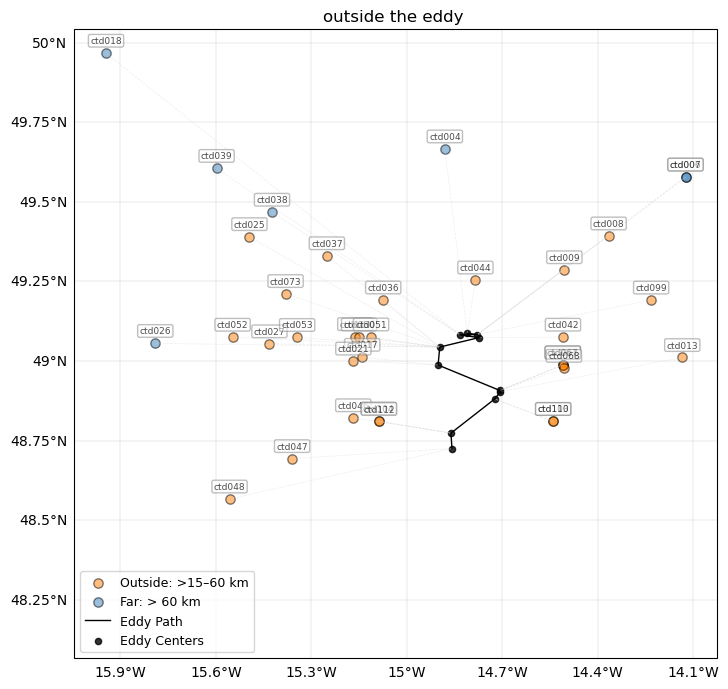

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from itertools import combinations

# Load the data
df = pd.read_excel("outside_eddy_result.xlsx")

# Rename the column for consistency
df = df.rename(columns={'location_category': 'eddy_classification'})

# Define colors and labels (removed "inside")
color_map = {
    "outside": ("#ff7f00", "Outside: >15–60 km"),
    "far": ("#377eb8", "Far: > 60 km")
}

# Create the map
plt.figure(figsize=(8, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor("white")

# Add geographic features
ax.coastlines(resolution='10m', linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='white')
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4)
gl.top_labels = gl.right_labels = False

# Draw dashed lines from CTD to eddy center
for _, row in df.iterrows():
    ax.plot([row["ctd_lon"], row["nearest_eddy_lon"]],
            [row["ctd_lat"], row["nearest_eddy_lat"]],
            color='lightgray', linewidth=0.5, alpha=0.4, linestyle='--')

# Scatter plot of CTDs by category (only outside and far)
for key in ["outside", "far"]:
    group = df[df["eddy_classification"] == key]
    ax.scatter(group["ctd_lon"], group["ctd_lat"],
               color=color_map[key][0],
               label=color_map[key][1],
               s=45, edgecolor='black', alpha=0.5)

# Plot eddy centers and path
eddy_centers = df[["nearest_eddy_lat", "nearest_eddy_lon"]].drop_duplicates()
eddy_centers_sorted = eddy_centers.sort_values(by=["nearest_eddy_lat", "nearest_eddy_lon"])
ax.plot(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
        color='black', linewidth=1, linestyle='-', label="Eddy Path")
ax.scatter(eddy_centers_sorted["nearest_eddy_lon"], eddy_centers_sorted["nearest_eddy_lat"],
           color='black', s=20, label="Eddy Centers", alpha=0.8)

# Map bounds
lon_min, lon_max = df["ctd_lon"].min() - 0.1, df["ctd_lon"].max() + 0.1
lat_min, lat_max = df["ctd_lat"].min() - 0.5, df["ctd_lat"].max() + 0.075
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# Label profile IDs for "outside" and "far" only
enable_labeling = True
if enable_labeling:
    for classification in ["outside", "far"]:
        group = df[df["eddy_classification"] == classification].copy()
        for i, (_, row) in enumerate(group.iterrows()):
            ax.text(row["ctd_lon"], row["ctd_lat"] + 0.025, str(row["profileid"]),
                    fontsize=6.5, ha='center', va='bottom',
                    color='black', alpha=0.7,
                    bbox=dict(facecolor='white', edgecolor='gray',
                              boxstyle='round,pad=0.2', alpha=0.5))

# Final touch
plt.title("outside the eddy ", fontsize=12)
plt.legend(title="", loc='lower left', fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.show()

